# Exercice 1 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

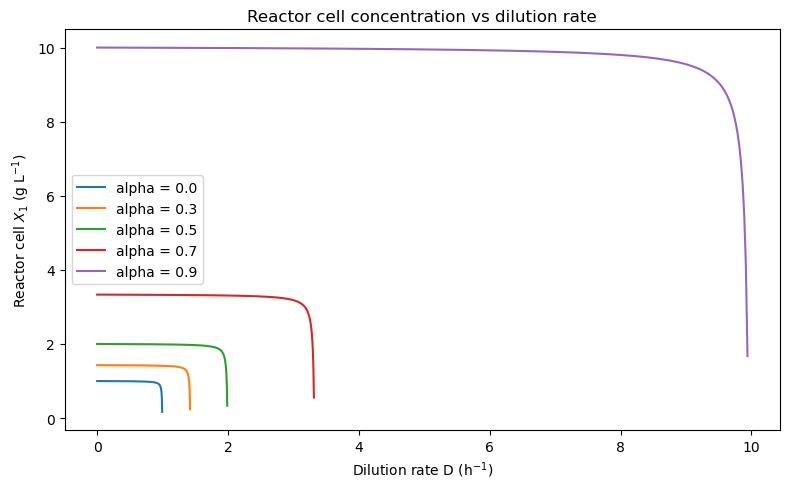

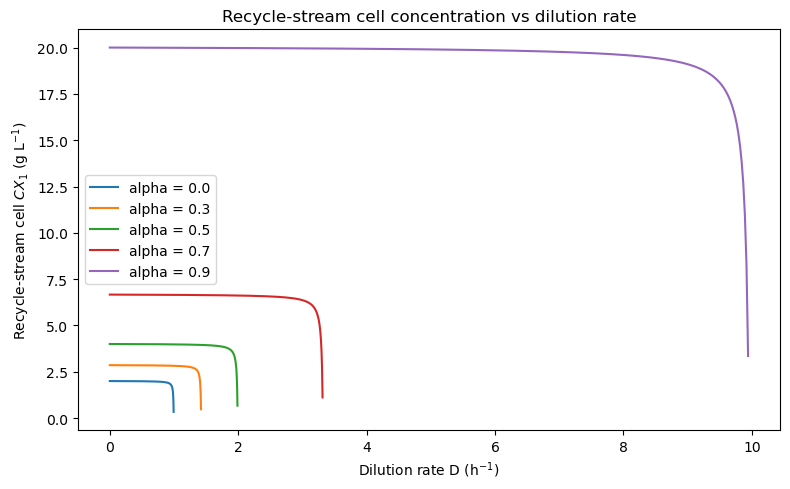

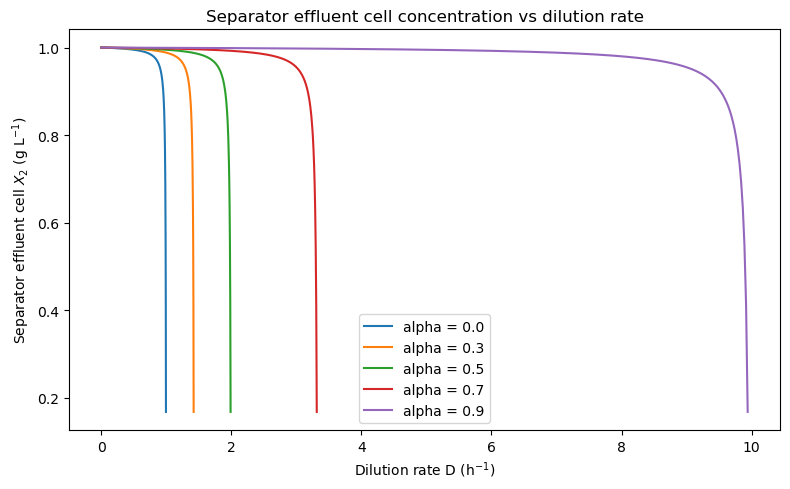

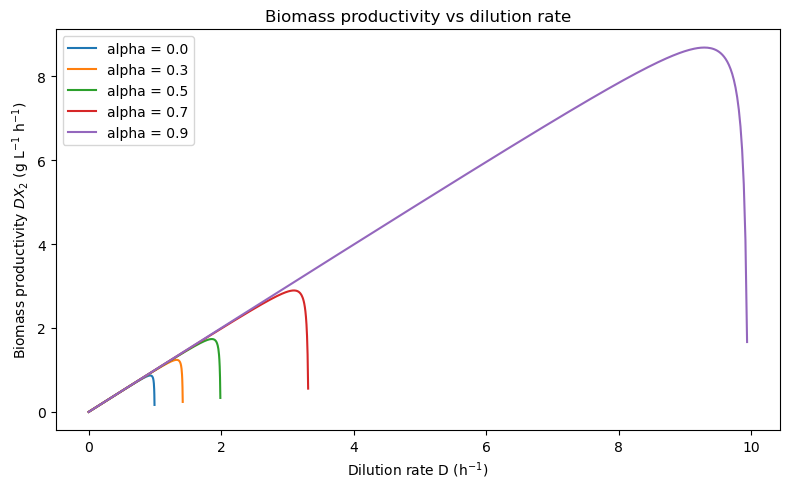


Dmax values:
alpha = 0.0 --> Dmax = 0.9950 h^-1
alpha = 0.3 --> Dmax = 1.4215 h^-1
alpha = 0.5 --> Dmax = 1.9900 h^-1
alpha = 0.7 --> Dmax = 3.3167 h^-1
alpha = 0.9 --> Dmax = 9.9502 h^-1


In [8]:
mu_max = 1.0      # h^-1
Ks = 0.01         # g/L
Yxs = 0.5         # g cells / g substrate
S0 = 2.0          # g/L
C = 2.0

alpha_values = [0.0, 0.3, 0.5, 0.7, 0.9]

def delta(alpha):
    return (1 + alpha) - alpha * C

def Dmax(alpha):
    d = delta(alpha)
    return mu_max * S0 / ((Ks + S0) * d)

def substrate_concentration(D, alpha):
    d = delta(alpha)
    return Ks * D * d / (mu_max - D * d)

def reactor_biomass(D, alpha):
    d = delta(alpha)
    S = substrate_concentration(D, alpha)
    return Yxs * (S0 - S) / d

def recycle_biomass(D, alpha):
    return C * reactor_biomass(D, alpha)

def separator_effluent_biomass(D, alpha):
    return delta(alpha) * reactor_biomass(D, alpha)

def biomass_productivity(D, alpha):
    return D * separator_effluent_biomass(D, alpha)

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, reactor_biomass(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Reactor cell $X_1$ (g L$^{-1}$)')
plt.title('Reactor cell concentration vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, recycle_biomass(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Recycle-stream cell $C X_1$ (g L$^{-1}$)')
plt.title('Recycle-stream cell concentration vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, separator_effluent_biomass(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Separator effluent cell $X_2$ (g L$^{-1}$)')
plt.title('Separator effluent cell concentration vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, biomass_productivity(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Biomass productivity $D X_2$ (g L$^{-1}$ h$^{-1}$)')
plt.title('Biomass productivity vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

print('\nDmax values:')
for alpha in alpha_values:
    print(f'alpha = {alpha:.1f} --> Dmax = {Dmax(alpha):.4f} h^-1')
